In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import unicodedata
import re
from google.colab import files
from google.colab import drive
drive.mount("/content/drive")



Mounted at /content/drive


In [ ]:
df1 = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/countries.csv")
df2 = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/events.csv")
df3 = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/products.csv")


In [ ]:
# 1. Tratamento de dados

df1.head()
#df1.info()
print(df1.dtypes) # Tipos de dados corretos.
#print(df1.isna().sum()) # Valores em um percentual abaixo de 0,004% foram encontrados e retirados da tabela.
ecom1 = df1.dropna()
print(ecom1.isna().sum())
ecom1.head() # São os novos valores após o tratamento.



name          object
alpha-2       object
alpha-3       object
region        object
sub-region    object
dtype: object
name          0
alpha-2       0
alpha-3       0
region        0
sub-region    0
dtype: int64


,name,alpha-2,alpha-3,region,sub-region
0,Afghanistan,AF,AFG,Asia,Southern Asia
1,Åland Islands,AX,ALA,Europe,Northern Europe
2,Albania,AL,ALB,Europe,Southern Europe
3,Algeria,DZ,DZA,Africa,Northern Africa
4,American Samoa,AS,ASM,Oceania,Polynesia


In [ ]:
# 1. Tratamento de dados

df2.head()
print(df2.dtypes) # Tipos de dados corretos.
#print(df2.isna().sum())
print(df2.isna().sum() / df2.shape[0]*100) # Mostra uma porcentagem de valores ausentes acima de 0,004%, portanto os dados ausentes na coluna country code são informativos demais para serem descartados.
df2['Country Code'] = df2['Country Code'].fillna('Unknown') # Preenchendo os valores ausentes com "Unkown" para simbolizar um código desconhecido.
df2['Sales Channel'] = df2['Sales Channel'].str.lower()
df2['Country Code'].unique()
df2.head()


Order ID            int64
Order Date         object
Ship Date          object
Order Priority     object
Country Code       object
Product ID          int64
Sales Channel      object
Units Sold        float64
Unit Price        float64
Unit Cost         float64
dtype: object
Order ID          0.000000
Order Date        0.000000
Ship Date         0.000000
Order Priority    0.000000
Country Code      6.165414
Product ID        0.000000
Sales Channel     0.000000
Units Sold        0.150376
Unit Price        0.000000
Unit Cost         0.000000
dtype: float64


,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost
0,100640618,10/8/2014,10/18/2014,M,NOR,2103,online,650.0,205.70,117.11
1,100983083,8/11/2016,8/11/2016,C,SRB,2103,offline,1993.0,205.70,117.11
2,101025998,7/18/2014,8/11/2014,M,Unknown,7940,online,4693.0,668.27,502.54
3,102230632,5/13/2017,6/13/2017,L,MNE,2455,online,1171.0,109.28,35.84
4,103435266,8/11/2012,9/18/2012,H,SRB,1270,offline,7648.0,47.45,31.79


In [ ]:
# 1. Tratamento de dados

df3.head()
print(df3.dtypes) # Tipos de dados corretos.
#print(df3.isna().sum()) # Valores em um percentual abaixo de 0,004% foram encontrados e retirados da tabela.
ecom3 = df3.dropna()
print(ecom3.isna().sum())
ecom3.head()

id            int64
item_type    object
dtype: object
id           0
item_type    0
dtype: int64


,id,item_type
0,2103,Cereal
1,7940,Household
2,2455,Clothes
3,1270,Beverages
4,8681,Office Supplies


In [ ]:
# 1. Tratamento de dados

def clean_string(s):
    if pd.isna(s):
        return s
    s = str(s)
    s = re.sub(r"[\u200B-\u200D\uFEFF]", "", s)   # caracteres invisíveis
    s = unicodedata.normalize("NFKC", s)         # unicode (latino/cirílico)
    s = s.strip()
    s = re.sub(r"\s+", " ", s)                    # espaços múltiplos
    s = unicodedata.normalize("NFKD", s)          # remover acentos
    s = "".join(c for c in s if not unicodedata.combining(c))
    return s



In [ ]:
# 1.1 Remoção de duplicatas

text_cols = ecom1.select_dtypes(include=["object", "string"]).columns
ecom1[text_cols] = ecom1[text_cols].applymap(clean_string)

print("Duplicates countries:", ecom1.duplicated().sum())
ecom1 = ecom1.drop_duplicates()

Duplicates countries: 0


/tmp/ipykernel_413/992550713.py:4: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ecom1[text_cols] = ecom1[text_cols].applymap(clean_string)
/tmp/ipykernel_413/992550713.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ecom1[text_cols] = ecom1[text_cols].applymap(clean_string)


In [ ]:
# 1.1 Remoção de duplicatas

text_cols = df2.select_dtypes(include=["object", "string"]).columns
df2[text_cols] = df2[text_cols].applymap(clean_string)

df2["Order Date"] = pd.to_datetime(df2["Order Date"], errors="coerce")
df2["Ship Date"]  = pd.to_datetime(df2["Ship Date"], errors="coerce")

print("Duplicatas events (Order ID):", df2.duplicated(subset=["Order ID"]).sum())
df2 = df2.drop_duplicates(subset=["Order ID"])

Duplicatas events (Order ID): 0


/tmp/ipykernel_413/1933447610.py:4: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df2[text_cols] = df2[text_cols].applymap(clean_string)


In [ ]:
# 1.1 Remoção de duplicatas

text_cols = ecom3.select_dtypes(include=["object", "string"]).columns
ecom3[text_cols] = ecom3[text_cols].applymap(clean_string)

print("Duplicatas products:", ecom3.duplicated(subset=["id"]).sum())
ecom3 = ecom3.drop_duplicates(subset=["id"])

Duplicatas products: 0


/tmp/ipykernel_413/985904514.py:4: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ecom3[text_cols] = ecom3[text_cols].applymap(clean_string)


In [ ]:
# 2. Anomalias
df2[df2["Ship Date"] < df2["Order Date"]]

df2[(df2["Unit Cost"] > df2["Unit Price"]) | (df2["Units Sold"] <= 0)]

df2.loc[~df2["Order Priority"].isin(["l","m","h","c"])]

# outliers simples (IQR)
Q1 = df2["Units Sold"].quantile(0.25)
Q3 = df2["Units Sold"].quantile(0.75)
IQR = Q3 - Q1

outliers = df2[
    (df2["Units Sold"] < Q1 - 1.5 * IQR) |
    (df2["Units Sold"] > Q3 + 1.5 * IQR)
]


In [ ]:
# 3. Análise e visualização de dados

# 3.1 União entre as três tabelas em um único dataframe.

df4 = pd.merge( df2, df3, left_on = "Product ID" , right_on = "id" , how = "left" )
#print(df4)

df5 = pd.merge( df4, df1, left_on = "Country Code", right_on = "alpha-3", how = "left")
print(df5)

# 3.2 Métricas chaves de desempenho

total_order = df5["Order ID"].count()
total_units_sold = df5["Units Sold"].sum()
total_revenue = (df5["Units Sold"] * df5["Unit Price"]).sum()
total_cost = (df5["Units Sold"] * df5["Unit Cost"]).sum()
total_profit = total_revenue - total_cost

total_country = df5["name"].count()
print(f"Total Countrys: {total_country}")

       Order ID Order Date  Ship Date Order Priority Country Code  Product ID  \
0     100640618 2014-10-08 2014-10-18              M          NOR        2103   
1     100983083 2016-08-11 2016-08-11              C          SRB        2103   
2     101025998 2014-07-18 2014-08-11              M      Unknown        7940   
3     102230632 2017-05-13 2017-06-13              L          MNE        2455   
4     103435266 2012-08-11 2012-09-18              H          SRB        1270   
...         ...        ...        ...            ...          ...         ...   
1325  994504153 2017-01-10 2017-01-13              M          SWE        4594   
1326  994978797 2014-12-05 2015-01-02              H          ITA        1270   
1327  996754205 2010-09-20 2010-09-22              L          RUS        7331   
1328  998043382 2010-06-15 2010-07-03              H          MLT        8293   
1329  999879729 2012-03-31 2012-05-06              M          ALB        7940   

     Sales Channel  Units S

In [ ]:
# 3.3 Análise de vendas
df5["Revenue"] = df5["Units Sold"] * df5["Unit Price"]
df5["Total Cost"] = df5["Units Sold"] * df5["Unit Cost"]
df5["Profit"] = df5["Revenue"] - df5["Total Cost"]



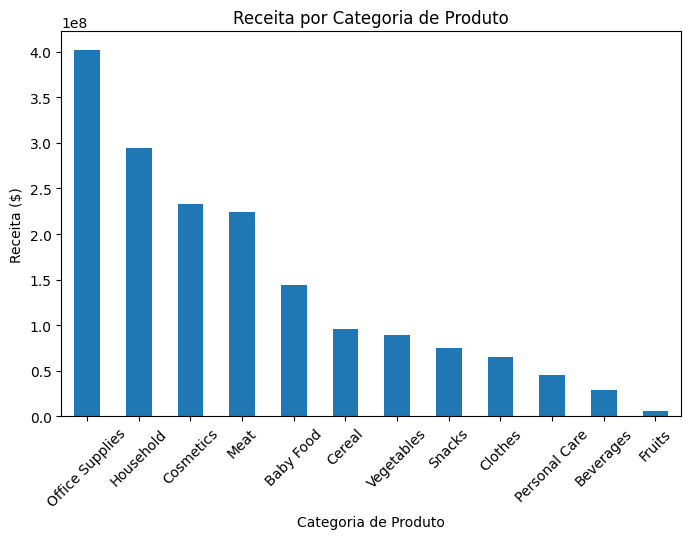

In [ ]:
# 3.3.1 Categoria de produtos - Gráfico

revenue_by_category = df5.groupby("item_type")["Revenue"].sum().sort_values(ascending=False)
plt.figure(figsize=(8,5))
revenue_by_category.plot(kind="bar")
plt.title("Receita por Categoria de Produto")
plt.xlabel("Categoria de Produto")
plt.ylabel("Receita ($)")
plt.xticks(rotation=45)
plt.show()

## Gráfico da Receita por Categoria de Produto

O gráfico acima mostra que a categoria de produto com maior receita se trata da categoria de material de escritório, com a receita em cerca de quatocentos mihões de dólares. ($ 400.000.000)

Já a categoria de produto que menos se tem receita, é a de frutas, não chegando a cinquenta mihões de dólares. ($ 50.000.000)

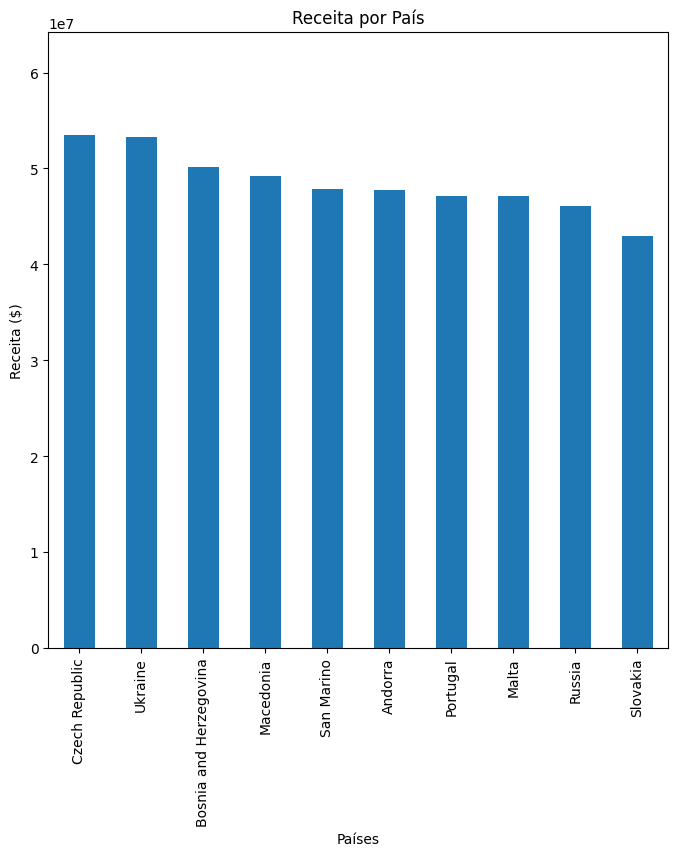

In [ ]:
# # 3.3.2.1 Geografia - Gráfico - País

revenue_by_country = df5.groupby("name")["Revenue"].sum().sort_values(ascending = False).head(10)
plt.figure(figsize=(8,8))
revenue_by_country.plot(kind = "bar")
plt.title("Receita por País")
plt.xlabel("Países")
plt.ylabel("Receita ($)")
plt.ylim(0, revenue_by_country.max() * 1.2)
plt.show()

## Receita por país

Esse gráfico trata da receita por cada país. O país com a maior contribuição para a receita da empresa se trata da Tchéquia com a receita em torno de cinquenta milhões de dólares ($ 50.000.000).



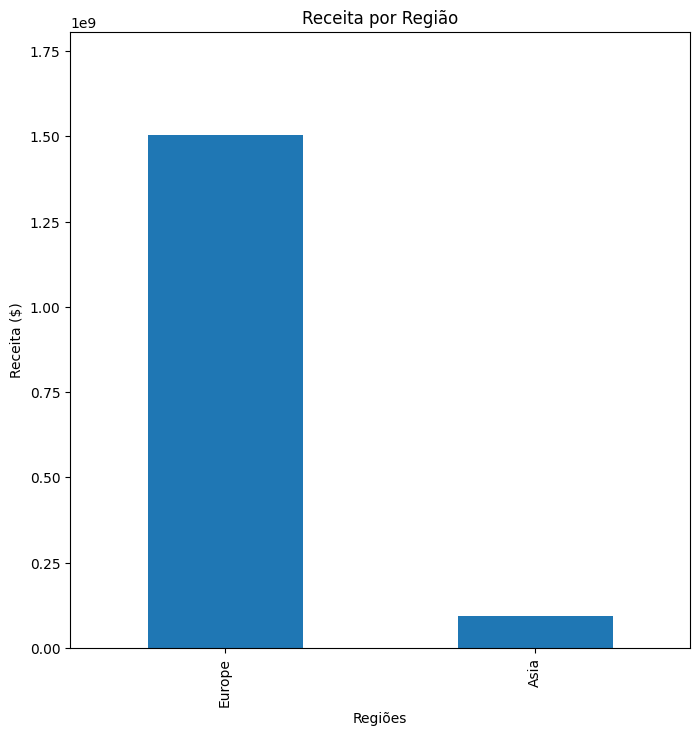

In [ ]:
# # 3.3.2.2 Geografia - Gráfico - Região

revenue_by_country = df5.groupby("region")["Revenue"].sum().sort_values(ascending = False).head(10)
plt.figure(figsize=(8,8))
revenue_by_country.plot(kind = "bar")
plt.title("Receita por Região")
plt.xlabel("Regiões")
plt.ylabel("Receita ($)")
plt.ylim(0, revenue_by_country.max() * 1.2)
plt.show()

Receita por Região

Trata da receita de cada região, podendo ser possível observar a disparidade entre a região da Europa, que é gera muito mais receita do que a região da Ásia. Os valores são, aproximadamente:

Europa : $ 1.500.000.000

Asia : $ 125.000.000

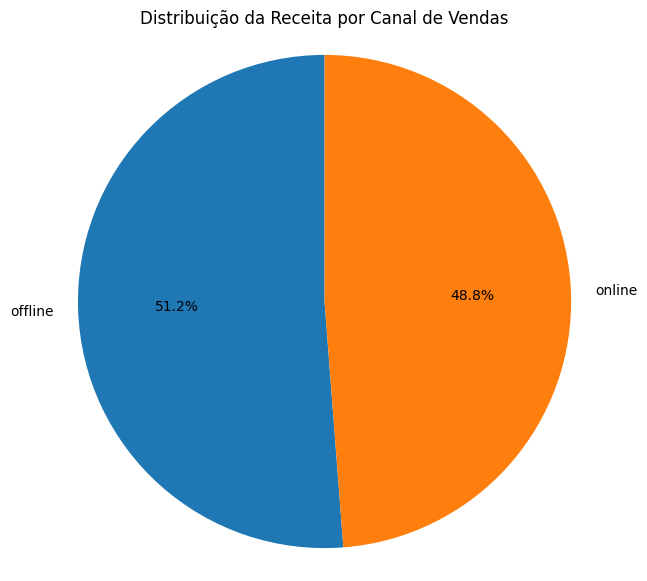

In [ ]:
# # 3.3.3 Canais de vendas - Gráfico

revenue_by_channel = df5.groupby("Sales Channel")["Revenue"].sum()
revenue_percent = revenue_by_channel / revenue_by_channel.sum() * 100
plt.figure(figsize= (7,7))
plt.pie(revenue_percent,labels = revenue_by_channel.index,autopct = "%1.1f%%",startangle = 90)
plt.title("Distribuição da Receita por Canal de Vendas")
plt.axis("equal")
plt.show()



O gráfico em pizza mostra um equilíbrio entre as compras virtuais e físicas, de acordo com a receita. Atualmente, a empresa ainda lucra mais com as vendas offline, com 51.2 % da receita advindo das compras físicas, enquanto o canal de vendas online é responsável por 48,8 % da receita.

In [ ]:
# 3.4 Análise do intervalo de tempo
df5["Order Date"] = pd.to_datetime(df5["Order Date"])
df5["Ship Date"]  = pd.to_datetime(df5["Ship Date"])
df5["Delivery Time"] = df5["Ship Date"] - df5["Order Date"]
df5["Delivery Days"] = df5["Delivery Time"].dt.days
df5["Delivery Days"]


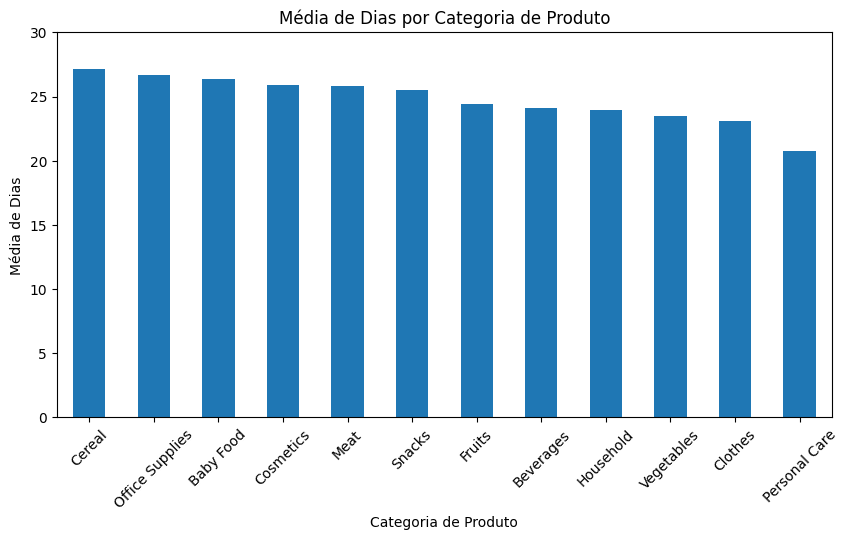

In [ ]:
# 3.4.1 Categoria de Produtos - Gráfico

days_mean_by_item_type = df5.groupby("item_type")["Delivery Days"].mean().sort_values(ascending = False)
plt.figure(figsize = (10,5))
days_mean_by_item_type.plot(kind = "bar")
plt.title("Média de Dias por Categoria de Produto")
plt.xlabel("Categoria de Produto")
plt.ylabel("Média de Dias")
plt.ylim(0, 30)
plt.xticks(rotation = 45)
plt.show()

## Média de Dias por Categoria de Produto

Nesse gráfico, relaciona-se em média quantos dias se demora entre o dia de pedido de um produto até a sua entrega, de acordo com a categoria de produtos. A categoria de produto que mais demora a chegar ao consumidor, trata-se dos cereais, demorando mais de 25 dias.


Já a categoria com a entrega mais rápida se trata dos produtos de cuidado pessoal, com a entrega demorando em média pouco mais de 20 dias.


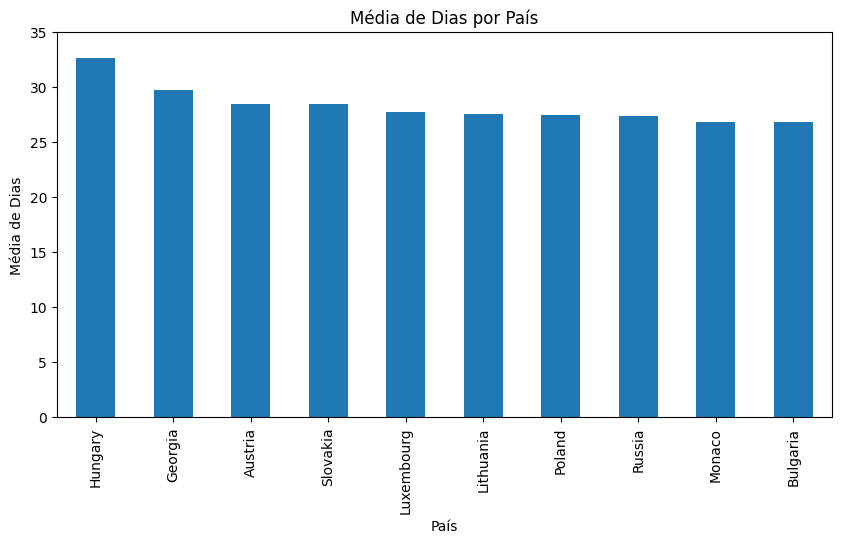

In [ ]:
# 3.4.2 Países - Gráfico
days_mean_by_country = df5.groupby("name")["Delivery Days"].mean().sort_values(ascending = False).head(10)
plt.figure(figsize = (10,5))
days_mean_by_country.plot(kind = "bar")
plt.title("Média de Dias por País")
plt.xlabel("País")
plt.ylabel("Média de Dias")
plt.ylim(0,35)
plt.show()

Nesse gráfico, relaciona-se em média quantos dias se demora entre o dia de pedido de um produto até a sua entrega, de acordo com o país.

O produto com a maior média de dias, acima de 30, trata-se da Hungria.

Já o país com a menor média de dias, com cerca de 20 dias, trata-se da Croácia.

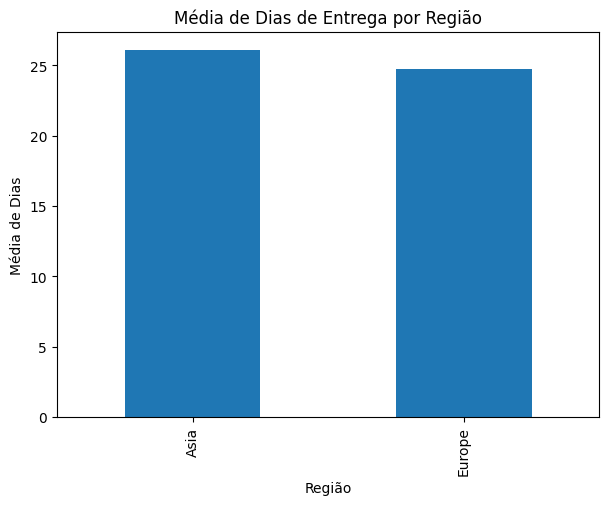

In [ ]:
# 3.4.3 Regiões - Gráfico

days_mean_by_region = df5.groupby("region")["Delivery Days"].mean().sort_values(ascending = False)

plt.figure(figsize=(7,5))
days_mean_by_region.plot(kind="bar")
plt.title("Média de Dias de Entrega por Região")
plt.xlabel("Região")
plt.ylabel("Média de Dias")
plt.show()

## Média de Dias de Entrega por Região

O gráfico de barras mostra a média de dias de demora entre o dia do pedido e o dia de entrega, de acordo com a região.

Assim, é possível perceber que a Asia se trata da região com maior tempo de entrega, em média mais do que 25 dias. A Europa se trata da região com a menor média de dias, abaixo dos 25 dias.

/tmp/ipykernel_413/452290782.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  profit_by_range = df5.groupby("Delivery Range")["Profit"].mean()


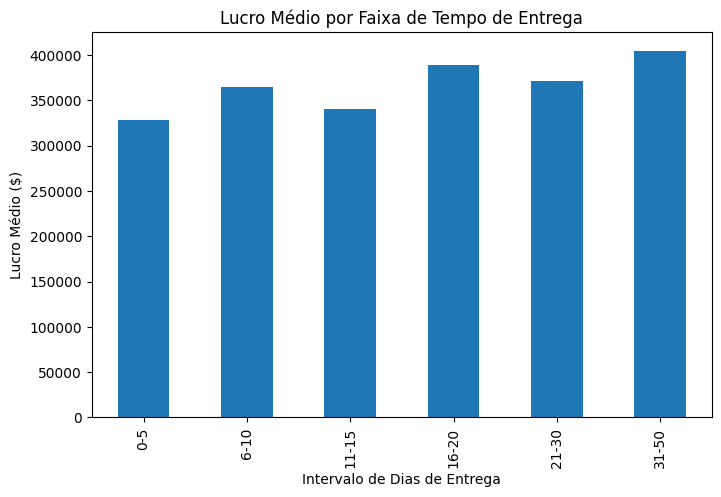

In [ ]:
# 3.5 Lucro pelo Tempo - Gráfico
df5["Delivery Range"] = pd.cut(
    df5["Delivery Days"],
    bins=[0,5,10,15,20,30,50],
    labels=["0-5","6-10","11-15","16-20","21-30","31-50"]
)

profit_by_range = df5.groupby("Delivery Range")["Profit"].mean()

profit_by_range.plot(kind="bar", figsize=(8,5))
plt.xlabel("Intervalo de Dias de Entrega")
plt.ylabel("Lucro Médio ($)")
plt.title("Lucro Médio por Faixa de Tempo de Entrega")
plt.show()

## Lucro Médio por Faixa de Tempo de Entrega

Esse gráfico serve para ilustrar se o intervalo de dias de entrega tem alguma relação com o lucro médio da empresa.

O gráfico mostra que os produtos que mais ocasionam lucro para a empresa, são também os que mais demoram para serem entregues, entre 31 a 50 dias para a entrega, ocasionando um lucro médio de quatrocentos mil dólares ($ 400.000).


Já os produtos que menos demoram para serem entregues, com no máximo 5 dias, são consecutivamente também os que menos geram lucro médio para a empresa, com um lucro de cerca de trezentos mil dólares ($ 300.000).

In [ ]:
df5["Order Date"] = pd.to_datetime(df5["Order Date"], errors="coerce")
df5["Ship Date"] = pd.to_datetime(df5["Ship Date"], errors="coerce")

df5["Year"] = df5["Order Date"].dt.year
df5["Month"] = df5["Order Date"].dt.month
df5["Period"] = df5["Order Date"].dt.to_period("M").dt.to_timestamp()
df5["Weekday"] = df5["Order Date"].dt.day_name()

df5["Revenue"] = df5["Units Sold"] * df5["Unit Price"]
df5["Cost"] = df5["Units Sold"] * df5["Unit Cost"]
df5["Profit"] = df5["Revenue"] - df5["Cost"]
df5["Quantity"] = df5["Units Sold"]

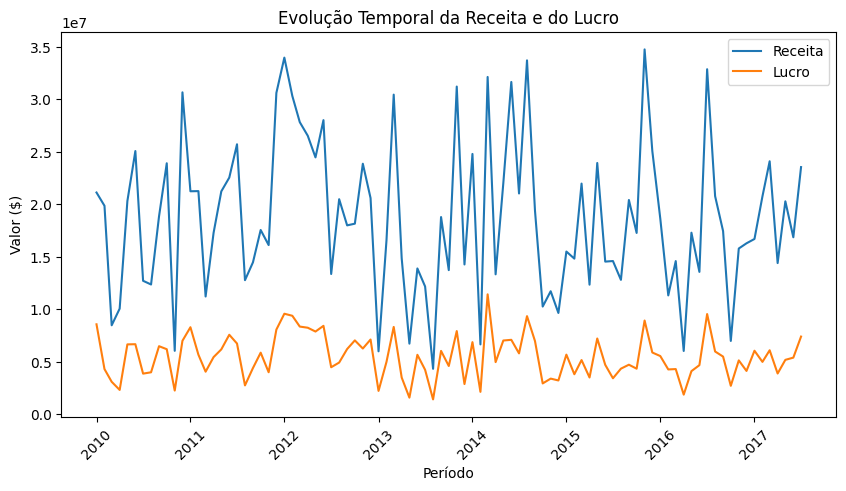

In [ ]:
ts_total = (df5.groupby("Period").agg(revenue=("Revenue", "sum"),profit=("Profit", "sum"),orders=("Order ID", "nunique")).reset_index())
plt.figure(figsize=(10,5))
plt.plot(ts_total["Period"], ts_total["revenue"], label="Receita")
plt.plot(ts_total["Period"], ts_total["profit"], label="Lucro")

plt.title("Evolução Temporal da Receita e do Lucro")
plt.xlabel("Período")
plt.ylabel("Valor ($)")
plt.legend()
plt.xticks(rotation=45)
plt.show()

## Evolução Temporal da Receita e do Lucro

Esse gráfico mostra a evolução do lucro e da receita da empresa ao longo dos anos, podendo ser perceptível os melhores e os piores anos da empresa no aspecto financeiro, em relação à receita e o lucro.

Período de pior lucro: Começo de 2010, final de 2010, meio de 2011, além de cerca de três vezes ao longo de 2013, que a empresa teve lucros bem próximo da margem mínima.
Período de maior lucro: Destaca-se principalmente 2014, posterior ao ínicio do ano.

Portanto, a receita e o lucro apresenta oscilações ao longo do ano, indicando a existência da sazonalidade de vendas.

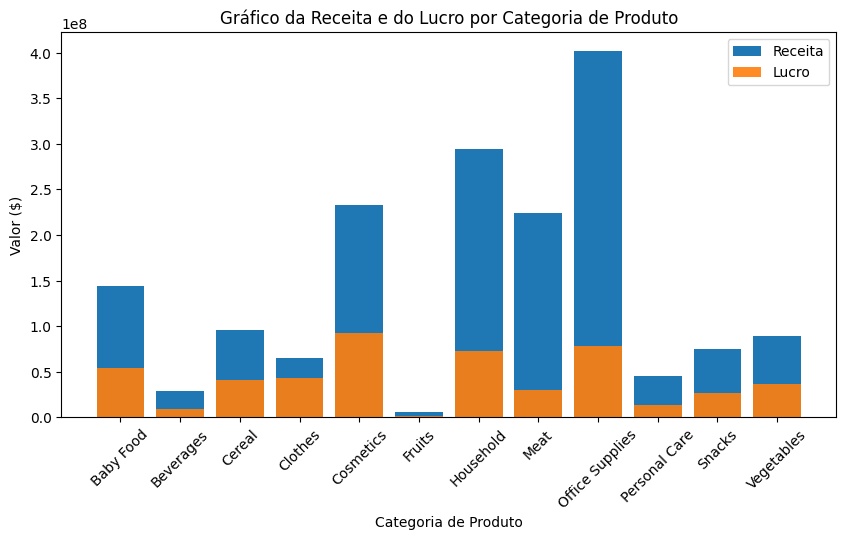

In [ ]:
ts_category = (df5.groupby("item_type").agg(revenue=("Revenue", "sum"),profit=("Profit", "sum"),orders=("Order ID", "nunique")).reset_index())
plt.figure(figsize = (10,5))
plt.bar(ts_category["item_type"], ts_category["revenue"], label = "Receita")
plt.bar(ts_category["item_type"], ts_category["profit"],label = "Lucro", alpha = 0.9)

plt.title("Gráfico da Receita e do Lucro por Categoria de Produto")
plt.xlabel("Categoria de Produto")
plt.ylabel("Valor ($)")
plt.legend()
plt.xticks(rotation = 45)
plt.show()


## Gráfico da Receita e do Lucro por Categoria de Produto

Um gráfico para destacar as categorias de produto com a maior receita e também o maior lucro.

Em relação a receita, os produtos que contribuiram em maior quantia para a receita da empresa se destaca o material de escritório.
Já em relação ao lucro, os cosméticos se destacam positivamente, se encontrando ligeiramente acima do produto com a maior receita, os materiais de escritório.

Essa diferença se dá pelo fato do custo de produção do material de escritório ser muito superior ao custo de produção dos cosméticos.

Já a categoria de produto com a menor receita e também o menor lucro, se trata das frutas.

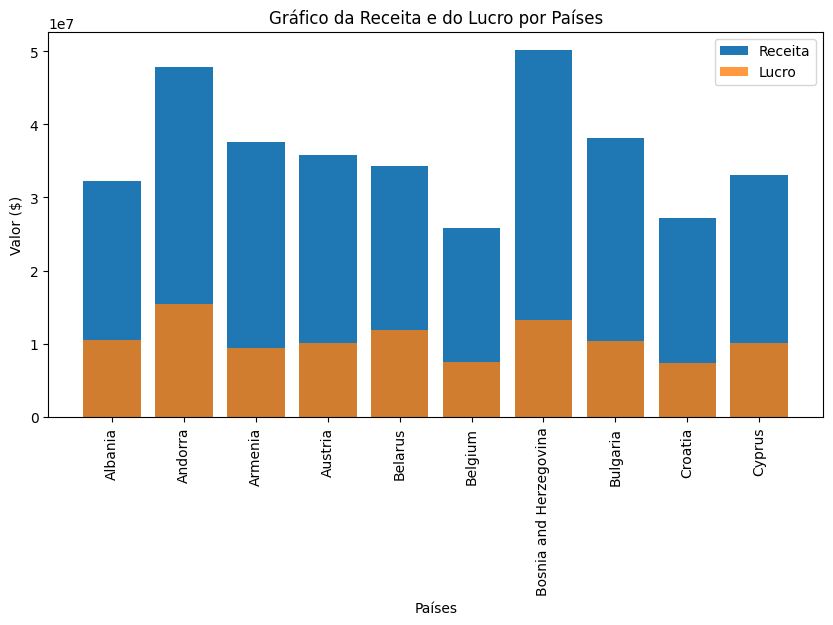

In [ ]:
ts_country = (df5.groupby("name").agg(revenue=("Revenue","sum"), profit = ("Profit","sum"),orders = ("Order ID","nunique")).reset_index().head(10))
plt.figure(figsize = (10,5))
plt.bar(ts_country["name"], ts_country["revenue"], label = "Receita")
plt.bar(ts_country["name"], ts_country["profit"], label = "Lucro", alpha = 0.8)

plt.title("Gráfico da Receita e do Lucro por Países")
plt.xlabel("Países")
plt.ylabel("Valor ($)")
plt.legend()
plt.xticks(rotation = 90)
plt.show()



## Gráfico da Receita e do Lucro por Países (top 10)

Em relação à receita, o país que contribuiu em maior parte para a receita da empresa se destaca a Tchéquia. Já o país que menos contribuiu para a receita bruta da empresa, nesse escopo, se destaca a Bélgica.

Já em relação ao lucro propriamente, o país mais lucrativo para a empresa, é o pais de Andorra. O menos lucrativo, nesse escopo, também é a Bélgica.

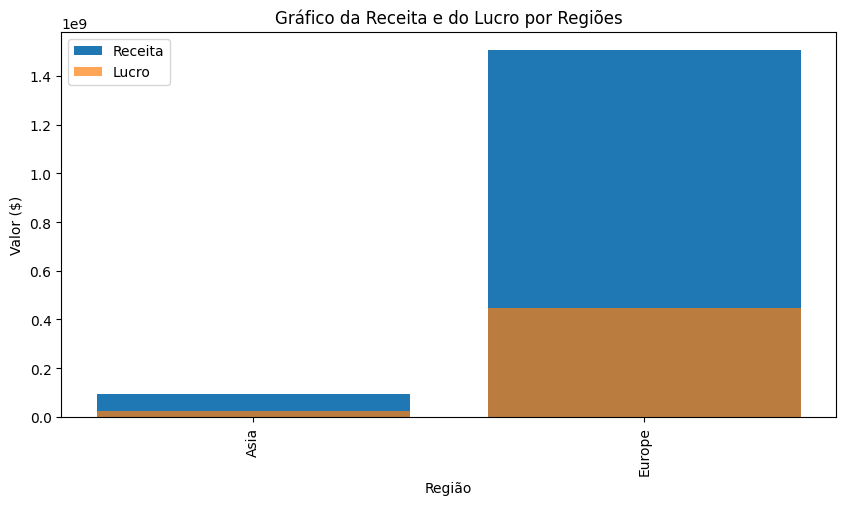

In [ ]:
ts_region = (df5.groupby("region").agg(revenue=("Revenue","sum"), profit = ("Profit","sum"),orders = ("Order ID","nunique")).reset_index())
plt.figure(figsize = (10,5))
plt.bar(ts_region["region"], ts_region["revenue"], label = "Receita")
plt.bar(ts_region["region"], ts_region["profit"], label = "Lucro", alpha = 0.7)

plt.title("Gráfico da Receita e do Lucro por Regiões")
plt.xlabel("Região")
plt.ylabel("Valor ($)")
plt.legend()
plt.xticks(rotation = 90)
plt.show()

## Gráfico da Receita e do Lucro por Regiões

O gráfico mostra a disparidade entre o lucro e receita entre as regiões que consomem os produtos da empresa. A Europa se consolida como a região que mais contribui com tanto o lucro quanto a receita da empresa.

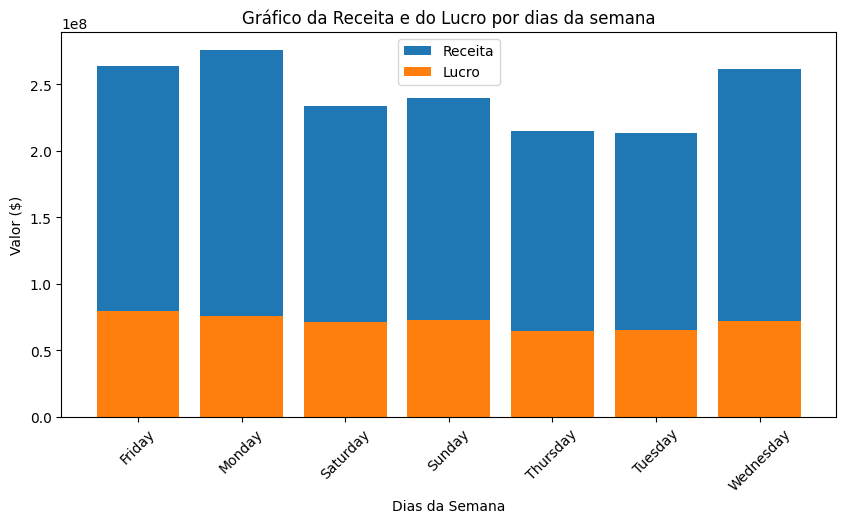

In [ ]:
df5["Day Name"] = df5["Order Date"].dt.day_name()
ts_day = (df5.groupby("Day Name").agg(revenue=("Revenue","sum"), profit = ("Profit", "sum"), orders = ("Order ID", "nunique")).reset_index())
plt.figure(figsize = (10,5))
plt.bar(ts_day["Day Name"], ts_day["revenue"], label = "Receita")
plt.bar(ts_day["Day Name"], ts_day["profit"], label = "Lucro")
plt.title("Gráfico da Receita e do Lucro por dias da semana")
plt.xlabel("Dias da Semana")
plt.ylabel("Valor ($)")
plt.legend()
plt.xticks(rotation = 45)
plt.show()

## Gráfico da Receita e do Lucro por dias da semana

O gráfico acima correlaciona o lucro e a receita de acordo com os dias da semana.

Em relação à receita, segunda-feira se trata do dia que gera uma maior receita para a empresa. O com a menor receita, se trata da terça-feira.

Já em relação ao lucro, sexta-feira e quarta-feira se equiparam como os dias da semana mais lucrativos. Entre os menos lucrativos, se equiparam tanto a quinta-feira quanto a terça-feira.

## Conclusões


A empresa apresenta em seu lucro uma oscilação ao longo do tempo, ou seja, uma sazonalidade de vendas. Acerca dos seus produtos, os materiais de escritório apresentam a maior receita bruta, entretanto por conta do elevado custo de produção, não se trata do mais lucrativo.
Para a categoria de produto mais lucrativa se encontram os cosméticos, que deveriam ser o foco principal da empresa se quiser arrecadar mais. Já as frutas, são o produto com menos receita e lucro, devendo haver menor investimento por parte da empresa.


O canal de venda mais utilizado se trata das vendas offline (51,2 %) , apesar das online terem um percentual considerável (48,8 %) e ainda haver a praticidade do negócio online. Assim, ambos os canais de vendas são uma alternativa válida e deveriam serem valorizados igualmente pela empresa.

Em relação aos países, ao analisar-se o escopo geral, o mais lucrativo se consta Andorra, um pequeno país da Europa. Apesar de ter uma população bem pouco numerosa, o alto lucro obtido pela empresa nesse país se explica pelo fato do país ter leis de compras com isenção de impostos. Já Mônaco, com a população sendo metade de Andorra, se trata do país menos lucrativo e também o com menos receita. Isso por ser na verdade um microestado soberano na Riviera Francesa, o que explica o baixo índice de compra da população.   

Em relação às regiões, a ásia apesar de haver uma maior média de tempo para entrega, é a região menos lucrativa para a empresa. Sendo assim uma opção menos favorável para a empresa, visto que apesar das entregas demorarem mais, se trata de uma região bem menos lucrativa se levar em conta a europa.


